# Figure1_2

In [1]:
from pathlib import Path

FIGURE_OUTPUT_DIR = Path("results/Figure1")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functions.load_data import loadTrialsM
from functions.utils import index_in, split_with_image
from functions.plotting import set_paper_theme

set_paper_theme()


## Panel D — Session learning curve

In [3]:
cr = []
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM("animate_vs_inanimate",monkey,verbose=True,islearn=False,extend=False)
    result_days = [ [tr["result"]=="CORRECT" for tr in _trials] for _trials in trials]
    _cr = [np.mean(_result) for _result in result_days]
    cr.append(_cr)

data_behavior/Monkey/animate_vs_inanimate/Elsa20230720_01_fmt.mat Trials Num:454
data_behavior/Monkey/animate_vs_inanimate/Elsa20230721_01_fmt.mat Trials Num:580
data_behavior/Monkey/animate_vs_inanimate/Elsa20230722_01_fmt.mat Trials Num:765
data_behavior/Monkey/animate_vs_inanimate/Elsa20230724_01_fmt.mat Trials Num:863
data_behavior/Monkey/animate_vs_inanimate/Elsa20230725_01_fmt.mat Trials Num:758
data_behavior/Monkey/animate_vs_inanimate/Elsa20230726_01_fmt.mat Trials Num:548
data_behavior/Monkey/animate_vs_inanimate/Elsa20230731_01_fmt.mat Trials Num:796
data_behavior/Monkey/animate_vs_inanimate/Judy20230512_01_fmt.mat Trials Num:552
data_behavior/Monkey/animate_vs_inanimate/Judy20230513_01_fmt.mat Trials Num:852
data_behavior/Monkey/animate_vs_inanimate/Judy20230515_01_fmt.mat Trials Num:772
data_behavior/Monkey/animate_vs_inanimate/Judy20230516_01_fmt.mat Trials Num:647
data_behavior/Monkey/animate_vs_inanimate/Judy20230517_01_fmt.mat Trials Num:693
data_behavior/Monkey/animate

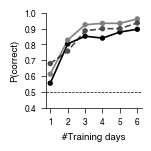

In [4]:
fig,ax = plt.subplots()
fig.set(figheight=105/75,figwidth=105/75)
colors = ["black","#808080","#4D4D4D"]
i = 0
ax.plot(range(6),cr[i][:6],linewidth=1.2,color=colors[i],zorder=1)
ax.scatter(range(6),cr[i][:6],s=15,color=colors[i],edgecolors='None',zorder=2)

i = 1
ax.plot(range(6),cr[i][:6],linewidth=1.2,color=colors[i],zorder=1)
ax.scatter(range(6),cr[i][:6],s=15,color=colors[i],edgecolors='None',zorder=2)

i = 2
ax.plot(range(6),cr[i][:6],linewidth=1.2,color=("black",0.7),linestyle="--",zorder=1)
ax.scatter(range(6),cr[i][:6],s=15,color=colors[i],edgecolors='None',zorder=2)


ax.axhline(0.5,color="black",linewidth=0.5,ls="--")

ax.set_xticks(range(6),[1,2,3,4,5,6])
ax.set_yticks([0.4,0.5,0.6,0.7,0.8,0.9,1])
ax.set_ylim([0.4,1])
ax.set_xlabel("#Training days")
ax.set_ylabel("P(correct)")

plt.savefig(FIGURE_OUTPUT_DIR / "learning_curve_days.pdf")
plt.show()

### Panel D inset — Repetition learning curve

In [5]:

crs = []
for monkey in ["Elsa","Judy","Olaf"]:
    trials,files = loadTrialsM("animate_vs_inanimate",monkey,verbose=True,islearn=False,two_target=False)
    trials_image,uimages = split_with_image(trials)
    repetition_matrix = np.zeros(shape=(len(uimages),30))
    for i in range(len(uimages)):
        _trials = trials_image[i][:30]
        cr = [tr["result"] == "CORRECT" for tr in _trials]
        one_target = [tr["hide_wrg_target"] == True for tr in _trials]
        repetition_matrix[i,:len(cr)] = cr
        repetition_matrix[i,one_target] = np.nan

    cr = np.zeros(30)
    for i in range(30):
        v = repetition_matrix[~np.isnan(repetition_matrix[:,i]),i]
        cr[i] = np.mean(v)

    crs.append(cr)


data_behavior/Monkey/animate_vs_inanimate/Elsa20230720_01_fmt.mat Trials Num:1044
data_behavior/Monkey/animate_vs_inanimate/Elsa20230721_01_fmt.mat Trials Num:758
data_behavior/Monkey/animate_vs_inanimate/Elsa20230722_01_fmt.mat Trials Num:779
data_behavior/Monkey/animate_vs_inanimate/Elsa20230724_01_fmt.mat Trials Num:863
data_behavior/Monkey/animate_vs_inanimate/Elsa20230725_01_fmt.mat Trials Num:758
data_behavior/Monkey/animate_vs_inanimate/Elsa20230726_01_fmt.mat Trials Num:548
data_behavior/Monkey/animate_vs_inanimate/Elsa20230731_01_fmt.mat Trials Num:796
data_behavior/Monkey/animate_vs_inanimate/Judy20230512_01_fmt.mat Trials Num:800
data_behavior/Monkey/animate_vs_inanimate/Judy20230513_01_fmt.mat Trials Num:852
data_behavior/Monkey/animate_vs_inanimate/Judy20230515_01_fmt.mat Trials Num:772
data_behavior/Monkey/animate_vs_inanimate/Judy20230516_01_fmt.mat Trials Num:647
data_behavior/Monkey/animate_vs_inanimate/Judy20230517_01_fmt.mat Trials Num:693
data_behavior/Monkey/animat

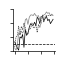

In [6]:
fig,ax = plt.subplots()
fig.set(figheight=40/75,figwidth=40/75)
colors = ["black","#808080","#4D4D4D"]

i = 0
ax.plot(range(30),crs[i],linewidth=0.5,color=colors[i],zorder=1)

i = 1
ax.plot(range(30),crs[i],linewidth=0.5,color=colors[i],zorder=1)

i = 2
ax.plot(range(30),crs[i],linewidth=0.5,color=colors[i],linestyle=(0, (2, 1)),zorder=1)

ax.axhline(0.5,color="black",linewidth=0.5,ls="--")

ax.set_xticks([0,10,20,30])
ax.set_xticklabels([])
ax.set_yticks([0.4,0.6,0.8,1])
ax.set_yticklabels([])
ax.set_ylim([0.4,1])
ax.tick_params( which='major', size=2) 
plt.savefig(FIGURE_OUTPUT_DIR / f"learning_curve_repetitions.pdf")
plt.show()

## Panels E–F — Per-image behavior

### Panel E — Per-image accuracy

In [7]:
trials = []
for monkey in ["Elsa","Judy","Olaf"]:
    _trials,files = loadTrialsM("animate_vs_inanimate",monkey,verbose=True)
    trials.extend(_trials)

trials_image,uimages = split_with_image(trials)
p,se1,rt,se2 = [],[],[],[]
for i in range(len(uimages)):
    _p = np.mean([tr["result"]=="CORRECT" for tr in trials_image[i]])
    _se1 = np.sqrt(_p*(1-_p)/len(trials_image[i]))
    _rt = np.mean([tr["rt"] for tr in trials_image[i]])
    _se2 = np.std([tr["rt"] for tr in trials_image[i]])/np.sqrt(len(trials_image[i]))
    p.append(_p)
    se1.append(_se1)
    rt.append(_rt)
    se2.append(_se2)

df = pd.DataFrame({"image":uimages,"p":p,"se_p":se1,"rt":rt,"se_rt":se2})
df = df.sort_values("p")


data_behavior/Monkey/animate_vs_inanimate/Elsa20230722_01_fmt.mat Trials Num:765
data_behavior/Monkey/animate_vs_inanimate/Elsa20230724_01_fmt.mat Trials Num:863
data_behavior/Monkey/animate_vs_inanimate/Elsa20230725_01_fmt.mat Trials Num:758
data_behavior/Monkey/animate_vs_inanimate/Elsa20230726_01_fmt.mat Trials Num:548
data_behavior/Monkey/animate_vs_inanimate/Elsa20230731_01_fmt.mat Trials Num:796
data_behavior/Monkey/animate_vs_inanimate/Judy20230515_01_fmt.mat Trials Num:772
data_behavior/Monkey/animate_vs_inanimate/Judy20230516_01_fmt.mat Trials Num:647
data_behavior/Monkey/animate_vs_inanimate/Judy20230517_01_fmt.mat Trials Num:693
data_behavior/Monkey/animate_vs_inanimate/Judy20230518_01_fmt.mat Trials Num:755
data_behavior/Monkey/animate_vs_inanimate/Olaf20230811_01_fmt.mat Trials Num:986
data_behavior/Monkey/animate_vs_inanimate/Olaf20230815_01_fmt.mat Trials Num:1017
data_behavior/Monkey/animate_vs_inanimate/Olaf20230817_01_fmt.mat Trials Num:840
data_behavior/Monkey/animat

In [8]:
## example images
exp_img = ["020409401499.png","010505800294.png","040804901709.png",
            "040205401162.png","020302900796.png","040511000414.png"]
idx = index_in(exp_img,df.image)
df.iloc[idx]


,image,p,se_p,rt,se_rt
69,020409401499.png,0.346535,0.047350,0.970158,0.043735
14,010505800294.png,0.405660,0.047692,0.940447,0.039281
95,040804901709.png,0.927273,0.024760,0.869922,0.044338
78,040205401162.png,0.941176,0.023298,0.829032,0.028675
56,020302900796.png,0.968750,0.017758,0.770968,0.027482
86,040511000414.png,0.972973,0.015392,0.858641,0.047343


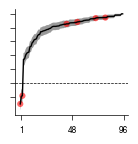

In [9]:
fig,ax = plt.subplots()
fig.set(figwidth=95/75,figheight=100/75)

ax.fill_between(range(len(df.p)),df.p-df.se_p,df.p+df.se_p,color="black",alpha=0.4,edgecolor="None")
ax.plot(range(len(df.p)),df.p,color="black",linewidth=1)
ax.scatter(idx,df.p.iloc[idx],color=("red",0.6),s=20,edgecolor="None")
ax.axhline(0.5,color="black",linewidth=0.5,linestyle="--")


ax.set_xticks([1,48,96])
ax.set_yticks([0.4,0.5,0.6,0.7,0.8,0.9,1])
ax.set_yticklabels([])
ax.set_xlim([-5,100])



plt.savefig(FIGURE_OUTPUT_DIR / f"accuracy_by_image.pdf",transparent=True)
plt.show()

## Panel F — Per-image RT

In [10]:
df = df.sort_values("rt")

## example images
exp_img = ["020409401499.png","010505800294.png",
            "040205401162.png","020302900796.png","040511000414.png"]
idx = index_in(exp_img,df.image)
df.iloc[idx]

,image,p,se_p,rt,se_rt
69,020409401499.png,0.346535,0.047350,0.970158,0.043735
14,010505800294.png,0.405660,0.047692,0.940447,0.039281
78,040205401162.png,0.941176,0.023298,0.829032,0.028675
56,020302900796.png,0.968750,0.017758,0.770968,0.027482
86,040511000414.png,0.972973,0.015392,0.858641,0.047343


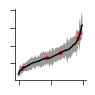

In [11]:
fig,ax = plt.subplots()
fig.set(figwidth=63/75,figheight=63/75)

ax.fill_between(range(len(df.rt)),df.rt-df.se_rt,df.rt+df.se_rt,color="black",alpha=0.4,edgecolor="None")
ax.plot(range(len(df.rt)),df.rt,color="black",linewidth=1)
ax.scatter(idx,df.rt.iloc[idx],color=("red",0.6),s=12,edgecolor="None")


ax.set_xticks([1,48,96])
ax.set_xticklabels([])
ax.set_yticks([0.8,0.9,1.0,1.1])
ax.set_yticklabels([])
ax.set_xlim([-5,100])



plt.savefig(FIGURE_OUTPUT_DIR / f"reaction_time_by_image.pdf",transparent=True)
plt.show()